## Notebook to examine data from Gurnani & Silver, 2021

### 1) Import required Python modules

Note: you can use `pip install -r requirements.txt` to install all the required packages

In [1]:
# Check all important packages can be imported
import matplotlib.pyplot as plt
import mat73
import pynwb
import sys

### 2) Load in the data from the original MATLAB format

In [2]:

sys.path.append("../python") # Add the path to the python directory
from LoadMatData import load_mat_file

original_experiment_id = "HG13__180827_12_28_17"

mat_file = f"../data/{original_experiment_id}.mat"

# Load the .mat file
neuron_df_f, neuron_times, speed, whisker_motion_index, state, pca_dff, puff_events, = load_mat_file(mat_file)


Loading data from: ../data/HG13__180827_12_28_17.mat
Variables in the .mat file: dict_keys(['allAnalysed', 'allData', 'allEvents'])
Neuron data (shape: (41, 14280))
Neuron times data (shape: (41, 14280))
Speed data (shape: (2, 186450))
Whisker motion index data (shape: (2, 120361))
State data (shape: (2, 120361))
PCA of dF/F data (shape: (9, 14280))
Puff event data (shape: (2, 20))


### 3) Generate some plots of the contained data

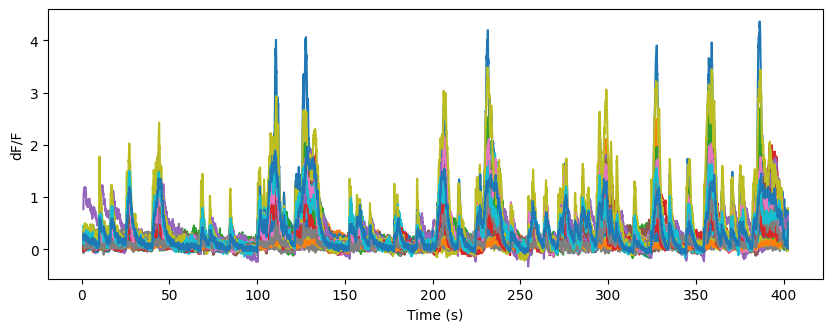

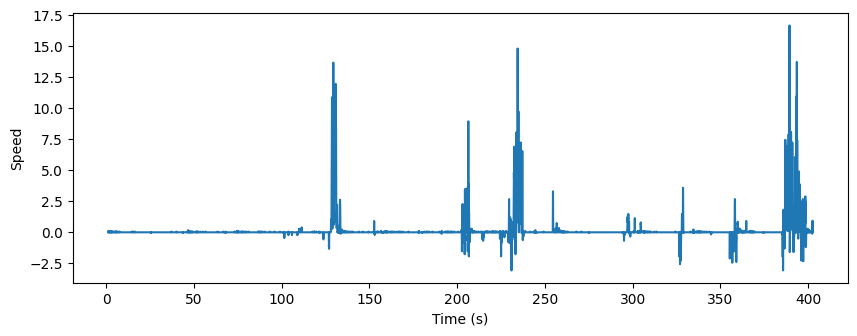

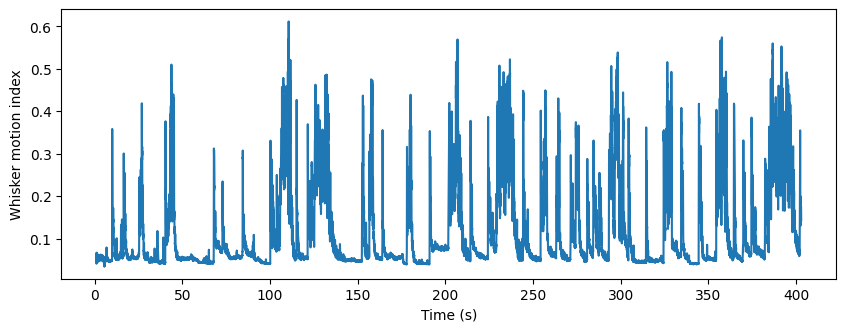

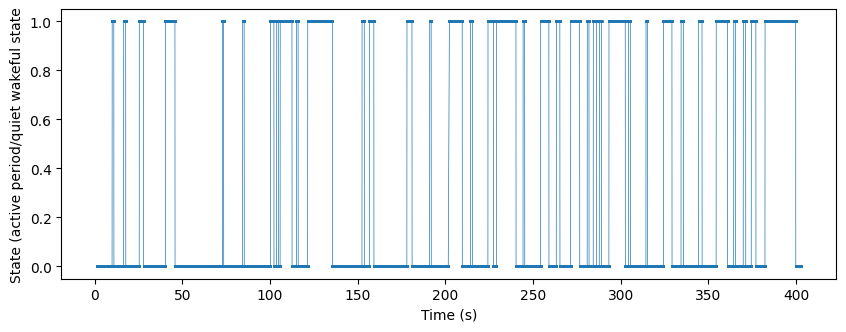

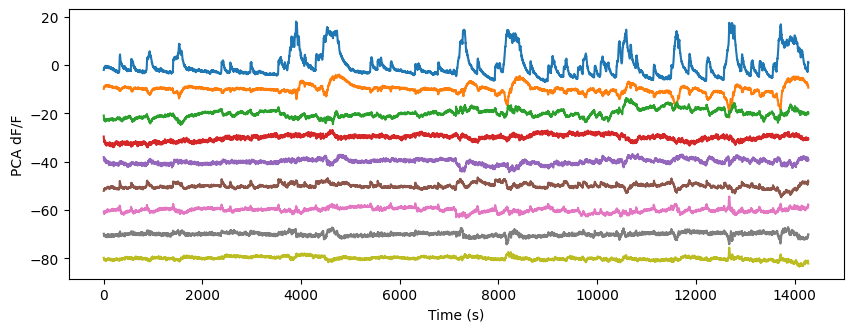

In [3]:
figsize=(10, 3.5)
plt.figure(figsize=figsize)

plt.xlabel("Time (s)")
plt.ylabel("dF/F")

for index in range(len(neuron_df_f)):
    plt.plot([t / 1000 for t in neuron_times[index]], neuron_df_f[index])

plt.figure(figsize=figsize)
plt.xlabel("Time (s)")
plt.ylabel("Speed")
plt.plot([t / 1000 for t in speed[0]], speed[1])

plt.figure(figsize=figsize)
plt.xlabel("Time (s)")
plt.ylabel("Whisker motion index")
plt.plot([t / 1000 for t in whisker_motion_index[0]], whisker_motion_index[1])

plt.figure(figsize=figsize)
plt.xlabel("Time (s)")
plt.ylabel("State (active period/quiet wakeful state")
plt.plot(
    [t / 1000 for t in state[0]], state[1], linewidth=0.5, marker=".", markersize=2
)

plt.figure(figsize=figsize)

plt.xlabel("Time (s)")
plt.ylabel("PCA dF/F")

for index in range(len(pca_dff)):
    plt.plot(pca_dff[index] + index * -10, label=f"PC {index+1}")

### 4) Generate a figure similar to Figure 1D in paper

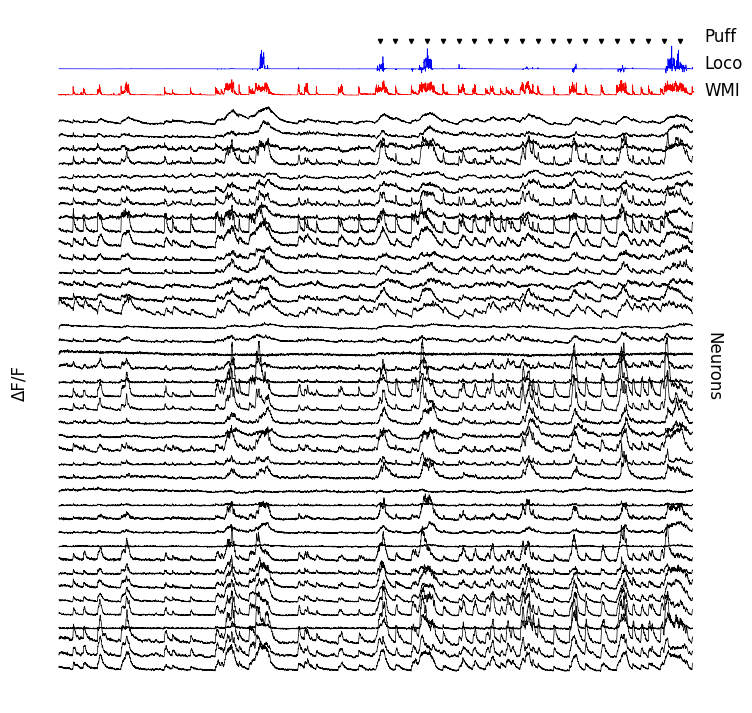

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))

plt.xlabel("Time (s)")
plt.ylabel("dF/F")

ax.set_axis_off()

offset = 1
for index in range(len(neuron_df_f)):
    plt.plot(
        [t / 1000 for t in neuron_times[index]],
        neuron_df_f[index] - index*offset,
        color="black",
        linewidth=0.5,
    )

plt.text(
    -30,
    -20,
    "ΔF/F",
    rotation=90,
    fontsize=12,
)
plt.text(
    410,
    -20,
    "Neurons",
    rotation=270,
    fontsize=12,
)

scale_wmi = 2
plt.plot([t / 1000 for t in whisker_motion_index[0]], whisker_motion_index[1]*scale_wmi+ 2*offset, color="red", linewidth=0.5)

plt.text(
    410,
    2,
    "WMI",
    fontsize=12,
)

scale_speed = 0.1
plt.plot([t / 1000 for t in speed[0]], speed[1]*scale_speed+ 4*offset, color="blue", linewidth=0.5)

plt.text(
    410,
    4,
    "Loco",
    fontsize=12,
)

if len(puff_events) > 0:
    for e in puff_events[0]:
        #print("Adding puff event at time %s" % (e / 1000))
        plt.plot(e / 1000, 6*offset, color="black", linestyle=None, marker="v", markersize=3)


plt.text(
    410,
    6,
    "Puff",
    fontsize=12,
)

plt.savefig(f"../data/Fig1D_{original_experiment_id}.png", dpi=300, bbox_inches="tight")

## My contribution: recreate Figure 3A from the paper

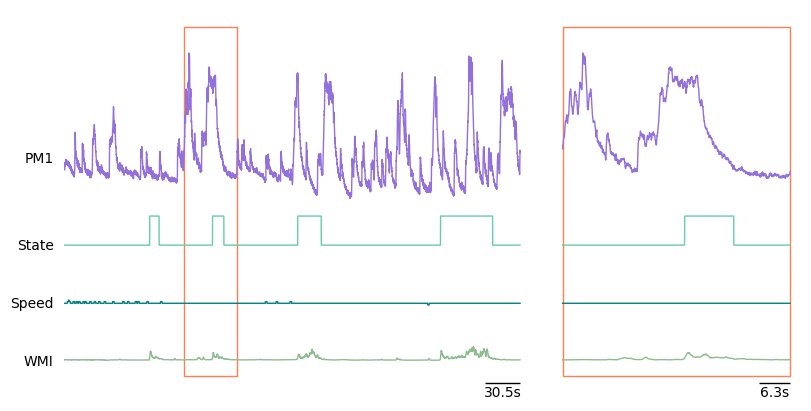

In [7]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

"""Create two subplots: ax1 = left plot; ax2 = right plot"""
fig, (ax1, ax2) = plt.subplots( # fig = whole canvas; axes = individual plots
    1, 2, # make a figure with 1 row & 2 columns of plots (so the subplots are horizontally adjacent)
    layout="constrained", # automatic spacing so the subplots don't overlap
    figsize=(8,4), # width, height of overall figure
    gridspec_kw={"width_ratios":[2,1]} # make ax1 twice as wide as ax2; gridspec_kw = "additional info for the subplot grid arrangement"
)

pm1 = pca_dff[0] # pca_dff contains several (8) PCA traces, so [0] lets us take the first one (PM1)

"""Create ax1.
        """
start_index1 = 0
stop_index1 = 14280 # pm1 trace is shorter than the others, so stop figure at the last value for pm1

ax1.plot(
    pm1[start_index1:stop_index1]*0.2 + 5, # 5 is a vertical shift so that it doesn't overlap with the other traces. *0.2 to compress the trace vertically to reduce spikes.
    linewidth=1,
    color="mediumpurple"
)
ax1.text(-350, 5, "PM1", ha="right", va="center") # label the traces

ax1.plot(
    state[1][start_index1:stop_index1] + 2, # choose [1] for state, speed, wmi because that's the values in the dataset (y-axis). [0] would give us time (x-axis).
    linewidth=1,
    color="mediumaquamarine"
)
ax1.text(-350, 2, "State", ha="right", va="center")

ax1.plot(
    speed[1][start_index1:stop_index1],
    linewidth=1,
    color="teal"
)
ax1.text(-350, 0, "Speed", ha="right", va="center")

ax1.plot(
    whisker_motion_index[1][start_index1:stop_index1] - 2,
    linewidth=1,
    color="darkseagreen"
)
ax1.text(-350, -2, "WMI", ha="right", va="center")



""" Adding timescale on bottom-right of ax1.
        """
bar_end1 = stop_index1
bar_start1 = bar_end1 - 1090
ax1.hlines(y=-2.75, xmin=bar_start1, xmax=bar_end1, color="black", linewidth=1) # the timescale line
time = neuron_times[0] # take time first row
ax1.text(
    (bar_start1 + bar_end1)/2, # mean = middle of the line
    -3.2, # below the line
    f"{((time[(bar_end1-1)] - time[bar_start1])/1000):.1f}s", # labelling the seconds of the timescale
    ha="center"
)



""" Create ax2.
        """
start_index2 = 3750
stop_index2 = 5400 # window of "interesting time period" seen in ax1 to zoom in on in ax2

ax2.plot(
    pm1[start_index2:stop_index2]*0.2 + 5,
    linewidth=1,
    color="mediumpurple"
)
ax2.plot(
    state[1][start_index2:stop_index2] + 2,
    linewidth=1,
    color="mediumaquamarine"
)
ax2.plot(
    speed[1][start_index2:stop_index2],
    linewidth=1,
    color="teal"
)
ax2.plot(
    whisker_motion_index[1][start_index2:stop_index2] - 2,
    linewidth=1,
    color="darkseagreen"
)

""" Adding timescale on bottom-right of ax2.
        """
bar_end2 = stop_index2 - start_index2
bar_start2 = bar_end2 - 225
ax2.hlines(y=-2.75, xmin=bar_start2, xmax=bar_end2, color="black", linewidth=1)
time = neuron_times[0]
ax2.text(
    (bar_start2 + bar_end2)/2,
    -3.2,
    f"{((time[(bar_end2 - 1)] - time[bar_start2])/1000):.1f}s",
    ha="center",
)



""" Formatting overall figures for ax1 & ax2
        """
for ax in (ax1, ax2): # general changes for both subplots
    ax.set_yticks([]) # remove y-axis ticks (values)
    ax.set_xticks([]) # remove x-axis ticks (time)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False) # remove subplot outlines
    
""" Adding patches (rectangles) to show time period of focus
        """
rect1 = patches.Rectangle(
    (start_index2, -2.5), # coordinates of where rectangle starts (bottom-left corner)
    (stop_index2 - start_index2), # width of rectangle = start_index2 & stop_index2 where we selected time period
    12, # height of rectangle
    linewidth=1,
    edgecolor="coral",
    facecolor="none" # "don't fill the rectangle in"
)
ax1.add_patch(rect1)

rect2 = patches.Rectangle(
    (0, -2.5),
    (stop_index2 - start_index2), # to cover entire subplot 2
    12,
    linewidth=1,
    edgecolor="coral",
    facecolor="none"
)
ax2.add_patch(rect2)

fig.savefig("GurnaniDataEllieFigure.png", dpi=300)